In [ ]:
import pandas as pd
import os

# Correct file path
train_path = os.path.join("mercari-price-suggestion-challenge", "train.tsv", "train.tsv")

# Read the file with error handling
try:
    # Try reading with Python engine which is more forgiving
    df = pd.read_csv(train_path, sep='\t', engine='python')
    print("Successfully loaded the data!")
    print(f"Number of rows: {len(df)}")
    print("\nFirst few rows:")
    display(df.head())
except Exception as e:
    print(f"Error loading the file: {e}")
    print("\nAvailable files in directory:")
    for root, dirs, files in os.walk("mercari-price-suggestion-challenge"):
        for file in files:
            print(os.path.join(root, file))''

Successfully loaded the data!
Number of rows: 1482535

First few rows:


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [2]:
# Fill missing descriptions and brand names
df['item_description'] = df['item_description'].fillna('')
df['brand_name'] = df['brand_name'].fillna('Unknown')

# Combine title and description for text features
df['text_features'] = df['name'] + " " + df['item_description']

# Optional: lowercase all text
df['text_features'] = df['text_features'].str.lower()


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack

# Text Vectorization
tfidf = TfidfVectorizer(max_features=5000)  # limit features for demo
text_vec = tfidf.fit_transform(df['text_features'])

# Encode categorical brand
le = LabelEncoder()
brand_vec = le.fit_transform(df['brand_name']).reshape(-1, 1)

# Combine sparse text with brand
from scipy.sparse import csr_matrix
X = hstack([text_vec, csr_matrix(brand_vec)])


In [4]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)


In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=20, random_state=42)  # 20 clusters as example
df['cluster'] = kmeans.fit_predict(X_reduced)

# Check cluster distribution
df['cluster'].value_counts()


c:\Users\jayas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cluster
1     721522
0      86677
5      74477
13     72771
11     55218
16     49349
9      42200
12     37233
19     36448
7      35466
10     35400
15     34137
14     29709
17     28698
4      28290
8      26658
2      25981
6      23695
18     19489
3      19117
Name: count, dtype: int64

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity of first 10 products (example)
similarity_matrix = cosine_similarity(X_reduced[:10])
print(similarity_matrix)


[[1.         0.99999998 0.99999998 0.99999998 0.99999998 0.99999999
  0.99998245 0.99999998 0.99999997 0.99999998]
 [0.99999998 1.         0.99999999 0.99999999 0.99999999 0.99999999
  0.99998249 0.99999999 0.99999997 0.99999999]
 [0.99999998 0.99999999 1.         0.99999999 0.99999999 0.99999999
  0.99998255 0.99999999 0.99999997 0.99999999]
 [0.99999998 0.99999999 0.99999999 1.         0.99999999 1.
  0.99998245 0.99999999 0.99999997 0.99999999]
 [0.99999998 0.99999999 0.99999999 0.99999999 1.         0.99999999
  0.99998241 0.99999999 0.99999997 0.99999999]
 [0.99999999 0.99999999 0.99999999 1.         0.99999999 1.
  0.99998251 0.99999999 0.99999998 1.        ]
 [0.99998245 0.99998249 0.99998255 0.99998245 0.99998241 0.99998251
  1.         0.99998251 0.99998256 0.99998246]
 [0.99999998 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
  0.99998251 1.         0.99999998 0.99999999]
 [0.99999997 0.99999997 0.99999997 0.99999997 0.99999997 0.99999998
  0.99998256 0.99999998 1.  

In [7]:
# Show first 10 items with their cluster assignments
df[['train_id', 'name', 'cluster']].head(10)

,train_id,name,cluster
0,0,MLB Cincinnati Reds T Shirt Size XL,1
1,1,Razer BlackWidow Chroma Keyboard,7
2,2,AVA-VIV Blouse,19
3,3,Leather Horse Statues,1
4,4,24K GOLD plated rose,1
5,5,Bundled items requested for Ruie,1
6,6,Acacia pacific tides santorini top,8
7,7,Girls cheer and tumbling bundle of 7,6
8,8,Girls Nike Pro shorts,0
9,9,Porcelain clown doll checker pants VTG,1


In [8]:
for i in range(5):  # show first 5 clusters
    print(f"Cluster {i}:")
    print(df[df['cluster']==i]['name'].head(5))
    print("\n")


Cluster 0:
8              Girls Nike Pro shorts
72            Listing for Aknuckles1
89                 Nike boy sneakers
91     Goosebumps HorrorLand DS Game
116         Lebron soldier 9s size 7
Name: name, dtype: object


Cluster 1:
0       MLB Cincinnati Reds T Shirt Size XL
3                     Leather Horse Statues
4                      24K GOLD plated rose
5          Bundled items requested for Ruie
9    Porcelain clown doll checker pants VTG
Name: name, dtype: object


Cluster 2:
211            Disneyland character key chain
256                     Brand New Men's Socks
303                                     Crocs
416    2 pair men's superman socks. Free ship
474         Nightmare Before Christmas Hoodie
Name: name, dtype: object


Cluster 3:
67              H&M Women's Long Horse Sweater
205         Hamilton Beach electric kettle 10C
234    Hello Kitty Orizuru Geisha Kimono Plush
252                Giorgio Armani Regenessence
344                    Gymshark crop bundle -L
Na

In [ ]:
import os 
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# If X_reduced doesn't exist, we'll need to recreate it
if 'X_reduced' not in locals() or X_reduced is None:
    print("Recreating reduced features...")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import LabelEncoder
    from scipy.sparse import hstack, csr_matrix
    from sklearn.decomposition import TruncatedSVD
    from sklearn.cluster import KMeans
    
    # Load the data
    train_path = os.path.join("mercari-price-suggestion-challenge", "train.tsv", "train.tsv")
    df = pd.read_csv(train_path, sep='\t', engine='python')
    
    # Preprocess
    df['item_description'] = df['item_description'].fillna('')
    df['brand_name'] = df['brand_name'].fillna('Unknown')
    df['text_features'] = df['name'] + " " + df['item_description']
    df['text_features'] = df['text_features'].str.lower()
    
    # Vectorize
    tfidf = TfidfVectorizer(max_features=5000)
    text_vec = tfidf.fit_transform(df['text_features'])
    le = LabelEncoder()
    brand_vec = le.fit_transform(df['brand_name']).reshape(-1, 1)
    X = hstack([text_vec, csr_matrix(brand_vec)])
    
    # Dimensionality reduction
    svd = TruncatedSVD(n_components=100, random_state=42)
    X_reduced = svd.fit_transform(X)
    
    # Clustering
    kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_reduced)

# Now perform t-SNE
print("Running t-SNE (this may take a while for large datasets)...")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(X_reduced[:5000])  # Using first 5000 samples for speed

# Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], 
                     c=df['cluster'].iloc[:5000],  # Match the samples used
                     cmap='tab20', 
                     s=5,
                     alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('t-SNE visualization of product clusters (first 5000 samples)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# Example: top 3 similar products for the first 5 products
for idx in range(5):
    sim_scores = similarity_matrix[idx]
    top_idx = np.argsort(sim_scores)[-4:-1][::-1]  # exclude itself
    print(f"Product {idx}: {df['name'].iloc[idx]}")
    print("Top similar products:")
    for i in top_idx:
        print(f" - {df['name'].iloc[i]} with similarity {sim_scores[i]:.4f}")
    print("\n")


Product 0: MLB Cincinnati Reds T Shirt Size XL
Top similar products:
 - Bundled items requested for Ruie with similarity 1.0000
 - Porcelain clown doll checker pants VTG with similarity 1.0000
 - 24K GOLD plated rose with similarity 1.0000


Product 1: Razer BlackWidow Chroma Keyboard
Top similar products:
 - AVA-VIV Blouse with similarity 1.0000
 - Porcelain clown doll checker pants VTG with similarity 1.0000
 - Bundled items requested for Ruie with similarity 1.0000


Product 2: AVA-VIV Blouse
Top similar products:
 - Bundled items requested for Ruie with similarity 1.0000
 - Porcelain clown doll checker pants VTG with similarity 1.0000
 - Razer BlackWidow Chroma Keyboard with similarity 1.0000


Product 3: Leather Horse Statues
Top similar products:
 - Bundled items requested for Ruie with similarity 1.0000
 - Porcelain clown doll checker pants VTG with similarity 1.0000
 - 24K GOLD plated rose with similarity 1.0000


Product 4: 24K GOLD plated rose
Top similar products:
 - Bundled

Recreating reduced features...
Running t-SNE (this may take a while for large datasets)...


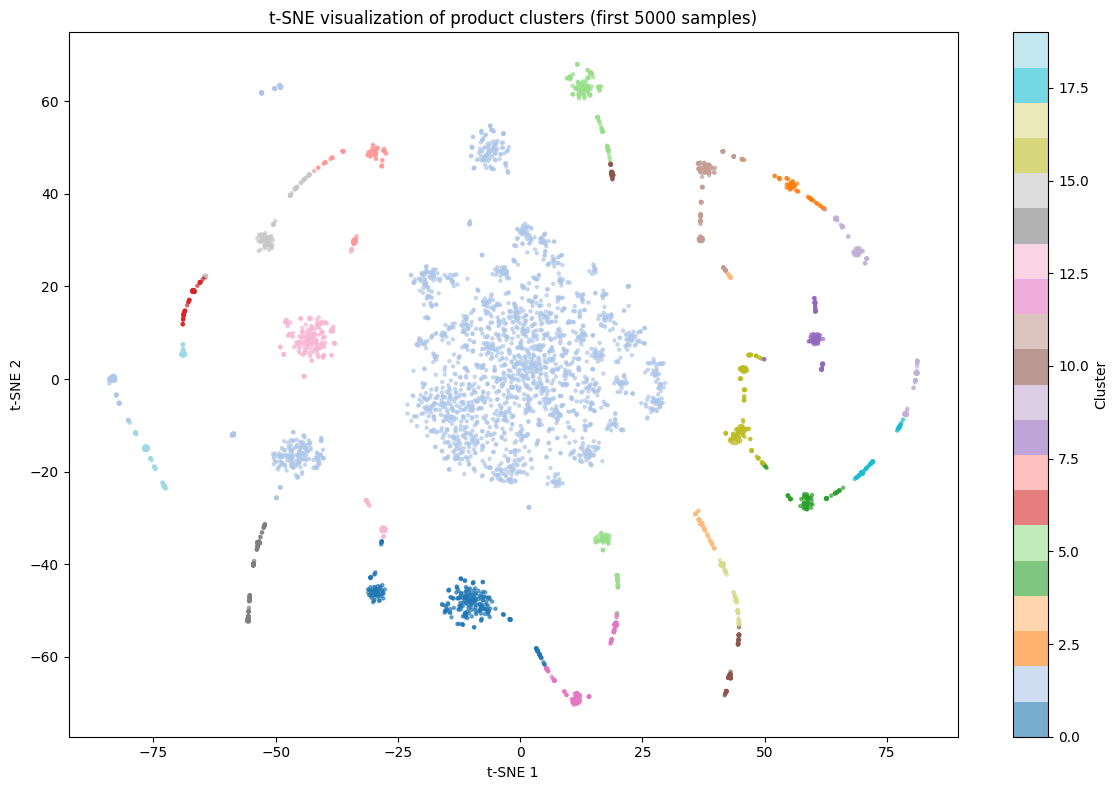

In [5]:
# First, let's make sure we have the required data
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import os

# If X_reduced doesn't exist, we'll need to recreate it
if 'X_reduced' not in locals() or X_reduced is None:
    print("Recreating reduced features...")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import LabelEncoder
    from scipy.sparse import hstack, csr_matrix
    from sklearn.decomposition import TruncatedSVD
    from sklearn.cluster import KMeans
    
    # Load the data
    train_path = os.path.join("mercari-price-suggestion-challenge", "train.tsv", "train.tsv")
    df = pd.read_csv(train_path, sep='\t', engine='python')
    
    # Preprocess
    df['item_description'] = df['item_description'].fillna('')
    df['brand_name'] = df['brand_name'].fillna('Unknown')
    df['text_features'] = df['name'] + " " + df['item_description']
    df['text_features'] = df['text_features'].str.lower()
    
    # Vectorize
    tfidf = TfidfVectorizer(max_features=5000)
    text_vec = tfidf.fit_transform(df['text_features'])
    le = LabelEncoder()
    brand_vec = le.fit_transform(df['brand_name']).reshape(-1, 1)
    X = hstack([text_vec, csr_matrix(brand_vec)])
    
    # Dimensionality reduction
    svd = TruncatedSVD(n_components=100, random_state=42)
    X_reduced = svd.fit_transform(X)
    
    # Clustering
    kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_reduced)

# Now perform t-SNE
print("Running t-SNE (this may take a while for large datasets)...")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(X_reduced[:5000])  # Using first 5000 samples for speed

# Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], 
                     c=df['cluster'].iloc[:5000],  # Match the samples used
                     cmap='tab20', 
                     s=5,
                     alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('t-SNE visualization of product clusters (first 5000 samples)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()